# M9 · Cold-start, Transfer & Distillation — Hands-on, Step by Tiny Step

**Companion to lesson M9. Written for someone new to ML.**

Every model faces a moment when it has **almost no data** but the product still has to
decide: a brand-new ad, a first-time visitor, a just-launched surface. That's **cold-start**.
This notebook shows the safe pattern — start from a **prior**, then hand off to the
**learned model** only once the evidence is strong enough — and then two ways to *reuse*
knowledge so you need fewer labels: **transfer learning** and **distillation**.

**What you'll do (every step has an explanation, logging, and a picture):**
- **Part A · Cold-start & the confidence blend:** why an early "2 clicks / 20 impressions"
  is a lie, how the blend `p = (1-c)·prior + c·learned` with `c = n/(n+k)` bridges safely,
  the exit criteria, and why this protects ad **budgets**.
- **Part B · Transfer learning:** reuse an **old model** on a new surface and **add new
  features** it never saw — see exactly how features are added and how training/inference
  flow, why it beats training from scratch on few labels, plus **negative transfer**.
- **Part C · Distillation:** train a small, fast **student** to imitate a strong, slow
  **teacher** — including **temperature** and "dark knowledge," and the quality-vs-latency
  tradeoff.

We use **scikit-learn** + **matplotlib** (no installs in Colab). Run each cell with
**Shift+Enter**.

## Step 1 · Setup

Just imports and a couple of colors. Each later step explains the ML idea before its code.

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"
print("ready")

ready


---
# Part A · Cold-start & the confidence blend

## Step 2 · What is cold-start? (and the trap)

**Cold-start** = the model has (almost) no history for something new. Three flavors:

| Type | What's missing | Example |
|---|---|---|
| **New item** | item interaction history | a brand-new Event Ad |
| **New user** | user history | a first-session visitor |
| **New system** | reliable labels | a just-launched surface |

The trap: a new ad gets **2 clicks in 20 impressions** — a raw CTR of **10%**. That looks
amazing, but 20 impressions is almost no evidence. If pacing believes it, budget floods a
noisy fluke. Let's *see* how unreliable a 20-impression rate is.

true CTR of every ad: 0.01  (1%)
yet observed 20-impression CTRs range from 0.0 to 0.15
share of ads that look like >=10% CTR by luck: 0.017


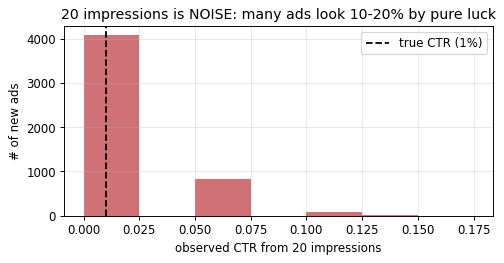

In [5]:
rng = np.random.default_rng(0)
true_ctr = 0.01                       # the REAL click rate for these new ads is a boring 1%
n_imps   = 20                         # but each new ad has only 20 impressions so far
observed = rng.binomial(n_imps, true_ctr, size=5000) / n_imps   # 5000 new ads' observed CTRs

print("true CTR of every ad:", true_ctr, " (1%)")
print("yet observed 20-impression CTRs range from", observed.min(), "to", observed.max())
print("share of ads that look like >=10% CTR by luck:", round((observed >= 0.10).mean(), 3))
plt.figure(figsize=(6,3.2))
plt.hist(observed, bins=np.arange(0, observed.max()+0.026, 0.025), color=RED, alpha=.8)
plt.axvline(true_ctr, color="k", ls="--", label="true CTR (1%)")
plt.xlabel("observed CTR from 20 impressions"); plt.ylabel("# of new ads"); plt.legend()
plt.title("20 impressions is NOISE: many ads look 10-20% by pure luck"); plt.show()

## Step 3 · The safe anchor — a **prior**

Instead of trusting 2/20, start from what **similar** items usually do. A **category prior**
might say "ads in this category average **1%** CTR." It's boring, but stable — it doesn't
swing with a couple of lucky clicks. Cold-start begins here.

In [7]:
p_prior = 0.01
print("category prior CTR:", p_prior, "-> our safe starting guess for ANY brand-new ad")
print("compare: the noisy '2 clicks / 20 impressions' raw estimate =", 2/20, "(way too hot)")

category prior CTR: 0.01 -> our safe starting guess for ANY brand-new ad
compare: the noisy '2 clicks / 20 impressions' raw estimate = 0.1 (way too hot)


## Step 4 · The confidence blend — the key formula

We don't want to ignore the ad's own data forever — just to **trust it in proportion to how
much of it there is**. The blend:
$$\hat p = (1-c_n)\,p_\text{prior} + c_n\,p_\text{learned},\qquad c_n=\frac{n}{n+k}$$
`c_n` is a **confidence dial** from 0 to 1. With `n` impressions and a constant `k`:
- tiny `n` → `c_n≈0` → we mostly trust the **prior**,
- huge `n` → `c_n≈1` → we mostly trust the ad's **own learned rate**.
`k` sets "how much evidence before I start trusting the data." Let's plot the dial.

  n=  20: c_n = 0.020
  n= 100: c_n = 0.091
  n=1000: c_n = 0.500
  n=5000: c_n = 0.833


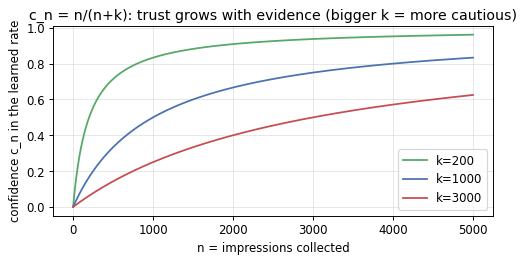

In [9]:
k = 1000
n = np.arange(0, 5001)
plt.figure(figsize=(6,3.2))
for kk, c in [(200, GREEN), (1000, BLUE), (3000, RED)]:
    plt.plot(n, n/(n+kk), color=c, label=f"k={kk}")
plt.xlabel("n = impressions collected"); plt.ylabel("confidence c_n in the learned rate")
plt.title("c_n = n/(n+k): trust grows with evidence (bigger k = more cautious)"); plt.legend(); plt.show()
for nv in [20, 100, 1000, 5000]:
    print(f"  n={nv:>4}: c_n = {nv/(nv+k):.3f}")

## Step 5 · The worked example from the lesson

Plug in the lesson's numbers: `p_prior=1%`, `p_learned=10%` (the hot 2/20 rate), `n=20`,
`k=1000`. The blend should stay near **1.18%**, *not* 10% — the 20 impressions barely move
us off the prior. Verify it exactly.

In [11]:
p_prior, p_learned, n, k = 0.010, 0.100, 20, 1000
c_n = n / (n + k)
p_blend = (1 - c_n) * p_prior + c_n * p_learned
print(f"c_n = {n}/({n}+{k}) = {c_n:.4f}")
print(f"blend = (1-{c_n:.4f})*{p_prior} + {c_n:.4f}*{p_learned} = {p_blend:.4f}  ({p_blend*100:.2f}%)")
assert round(p_blend, 4) == 0.0118
print("matches the lesson's 1.18% ✓  -> the early spike is tamed")

c_n = 20/(20+1000) = 0.0196
blend = (1-0.0196)*0.01 + 0.0196*0.1 = 0.0118  (1.18%)
matches the lesson's 1.18% ✓  -> the early spike is tamed


## Step 6 · Watch the handoff happen

Now follow **one** ad as impressions accumulate (true CTR 10%). Plot three lines:
- **prior** (flat 1%),
- **raw** running CTR (jumpy early, settles late),
- **blended** estimate — starts glued to the prior, then smoothly slides toward the truth.
This is the cold→warm handoff in one picture.

  n=  20: raw=0.100  blended=0.012  c_n=0.02
  n= 100: raw=0.110  blended=0.019  c_n=0.09
  n= 500: raw=0.104  blended=0.041  c_n=0.33
  n=1000: raw=0.080  blended=0.045  c_n=0.50
  n=3000: raw=0.093  blended=0.072  c_n=0.75


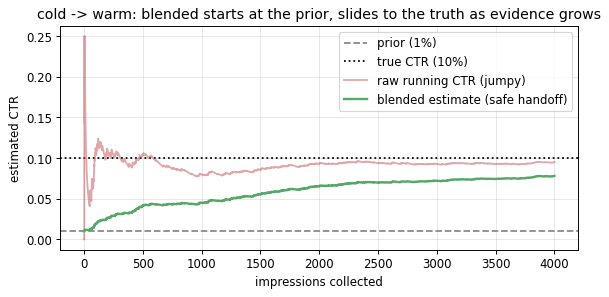

In [13]:
rng = np.random.default_rng(2)
true_ctr, p_prior, k = 0.10, 0.01, 1000
N = 4000
clicks = (rng.random(N) < true_ctr).astype(int)
imps = np.arange(1, N+1)
raw = np.cumsum(clicks) / imps
c_n = imps / (imps + k)
blend = (1 - c_n) * p_prior + c_n * raw

plt.figure(figsize=(7,3.6))
plt.axhline(p_prior, color=GRAY, ls="--", label="prior (1%)")
plt.axhline(true_ctr, color="k", ls=":", label="true CTR (10%)")
plt.plot(imps, raw, color=RED, alpha=.5, label="raw running CTR (jumpy)")
plt.plot(imps, blend, color=GREEN, lw=2, label="blended estimate (safe handoff)")
plt.xlabel("impressions collected"); plt.ylabel("estimated CTR"); plt.legend()
plt.title("cold -> warm: blended starts at the prior, slides to the truth as evidence grows"); plt.show()
for nv in [20, 100, 500, 1000, 3000]:
    print(f"  n={nv:>4}: raw={raw[nv-1]:.3f}  blended={blend[nv-1]:.3f}  c_n={c_n[nv-1]:.2f}")

## Step 7 · Exit criteria — log the regime, gate the handoff

Don't switch on a hunch. Define **gates** and label every score with the **regime** that
produced it, so later you can tell "the model is bad" from "we handed off too early":
- **cold** (trust prior) → **blended** → **warm** (trust learned) once, e.g., **≥1000
  impressions AND ≥20 clicks** with stable calibration.

     20 imps /   2 clicks  ->  regime = cold
    300 imps /   8 clicks  ->  regime = blended
   1200 imps /  25 clicks  ->  regime = warm
   5000 imps /  90 clicks  ->  regime = warm


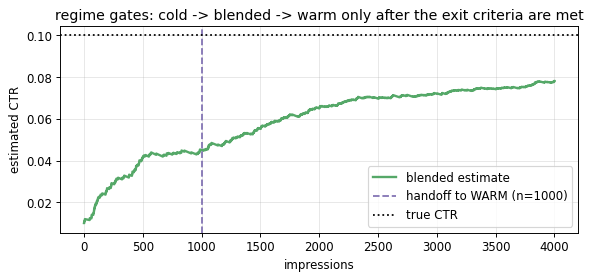

In [15]:
def regime(n_imps, n_clicks):
    if n_imps >= 1000 and n_clicks >= 20:
        return "warm"
    if n_imps >= 50:
        return "blended"
    return "cold"

for n_imps, n_clicks in [(20, 2), (300, 8), (1200, 25), (5000, 90)]:
    print(f"  {n_imps:>5} imps / {n_clicks:>3} clicks  ->  regime = {regime(n_imps, n_clicks)}")

cum_clicks = np.cumsum(clicks)
regimes = [regime(i, cum_clicks[i-1]) for i in imps]
first_warm = regimes.index("warm") + 1
plt.figure(figsize=(7,3.4))
plt.plot(imps, blend, color=GREEN, lw=2, label="blended estimate")
plt.axvline(first_warm, color=PURPLE, ls="--", label=f"handoff to WARM (n={first_warm})")
plt.axhline(0.10, color="k", ls=":", label="true CTR")
plt.xlabel("impressions"); plt.ylabel("estimated CTR"); plt.legend()
plt.title("regime gates: cold -> blended -> warm only after the exit criteria are met"); plt.show()

## Step 8 · Why it matters — protecting the **budget**

Pacing multiplies CTR by bid to spend budget. If it uses the **raw** early rate, it pours
money into lucky spikes. The **blend** keeps every new ad near the prior until it earns
trust — so budget follows the ad with real, sustained evidence, not the noisiest fluke.

              ad  raw CTR  blended CTR
  spike A (2/20) 0.100000     0.011765
  spike B (3/20) 0.150000     0.012745
      dud (0/20) 0.000000     0.009804
proven (25/1500) 0.016667     0.014000
raw would overspend on the 15% spike; blended ranks the proven ad highest. Budget stays safe.


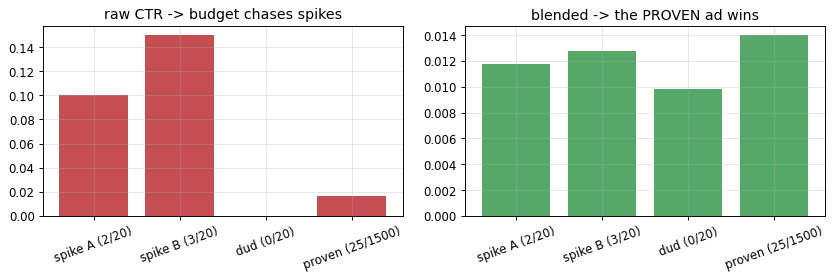

In [17]:
p_prior, k = 0.01, 1000
ads = [("spike A (2/20)", 2, 20), ("spike B (3/20)", 3, 20),
       ("dud (0/20)", 0, 20), ("proven (25/1500)", 25, 1500)]
rows = []
for name, c, n in ads:
    raw = c/n; cn = n/(n+k); bl = (1-cn)*p_prior + cn*raw
    rows.append((name, raw, bl))
df = pd.DataFrame(rows, columns=["ad", "raw CTR", "blended CTR"]); print(df.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
names = [r[0] for r in rows]
ax[0].bar(names, [r[1] for r in rows], color=RED);  ax[0].set_title("raw CTR -> budget chases spikes"); ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(names, [r[2] for r in rows], color=GREEN); ax[1].set_title("blended -> the PROVEN ad wins"); ax[1].tick_params(axis="x", rotation=20)
plt.show()
print("raw would overspend on the 15% spike; blended ranks the proven ad highest. Budget stays safe.")

---
# Part B · Transfer learning

## Step 9 · The scenario — reuse an OLD model on a NEW surface

Imagine your team already has a mature **events-ranking model** ("the **old model**"). It was
trained on **tons** of data using a rich set of **shared features** (audience fit, creative
quality, advertiser history, topic signals — 25 engineered features in total).

Now a **new Event Ads surface** launches. It has:
- the **same 25 shared features**, **plus**
- **2 brand-new features the old model never saw** — `is_video` (is the creative a video?)
  and `is_weekend` — and
- only a **few hundred labels** so far (it's new).

**The goal:** don't throw away the old model, and don't ignore the new features. We'll
**reuse the old model AND add the two new features** into a small **new model**. Along the
way you'll see exactly how a feature is "added," and how training and inference flow.

## Step 10 · Build the OLD model (trained on lots of data, shared features only)

First we create the old model. It learns the relationship between the **25 shared features**
and clicks from **40,000** rows — so it has genuinely mastered that signal. Keep in mind it
has **never seen** `is_video` or `is_weekend`; those didn't exist on the old surface.

In [21]:
D_SHARED = 25
gen = np.random.default_rng(0)
w_shared = gen.normal(0, 1, D_SHARED) * np.array([1.0]*6 + [0.25]*19)   # a few strong + many weak signals

def gen_shared(n, rng):
    return rng.normal(0, 1, (n, D_SHARED))     # 25 standardized engineered features (0 = average)

# OLD MODEL: the mature model, trained on 40k rows using the shared features ONLY
r = np.random.default_rng(1)
Xs = gen_shared(40000, r)
ys = (r.random(40000) < 1/(1 + np.exp(-(Xs @ w_shared - 0.3)))).astype(int)
old_model = LogisticRegression(max_iter=3000).fit(Xs, ys)
print(f"OLD model trained on {len(Xs):,} rows x {D_SHARED} shared features")
print(f"OLD model input width: {old_model.coef_.shape[1]} features  (it ONLY knows these 25)")

# The NEW task: same 25 shared features + 2 NEW ones (is_video, is_weekend), explained next.
w_new = np.array([1.6, -1.1])   # the true effect of the new features (video helps, weekend hurts)
def gen_new(n, seed):
    r = np.random.default_rng(seed)
    Xshared    = gen_shared(n, r)
    is_video   = r.integers(0, 2, n).astype(float)
    is_weekend = r.integers(0, 2, n).astype(float)
    Xextra     = np.column_stack([is_video, is_weekend])
    logit = Xshared @ w_shared + Xextra @ w_new - 0.3
    y = (r.random(n) < 1/(1 + np.exp(-logit))).astype(int)
    return Xshared, Xextra, y

# held-out test set for the NEW task (used later to score models)
Xsh_test, Xnew_test, y_test = gen_new(6000, 99)
print("OLD model AUC on the NEW task using shared signal only:",
      round(roc_auc_score(y_test, old_model.predict_proba(Xsh_test)[:, 1]), 3),
      "\n  -> decent, but it's blind to the 2 new features, so it's capped.")

OLD model trained on 40,000 rows x 25 shared features
OLD model input width: 25 features  (it ONLY knows these 25)
OLD model AUC on the NEW task using shared signal only: 0.767 
  -> decent, but it's blind to the 2 new features, so it's capped.


## Step 11 · The OLD model squashes MANY features into ONE number

Take **5 example impressions**. Each has the 25 shared features (a wide table). When we ask
the old model to score them, it turns each **row of 25 numbers into a single prediction** — a
click probability. That one number is the old model's whole opinion, distilled. Watch 25
columns become 1.

In [23]:
# 5 example impressions we'll follow all the way through
Xsh_demo, Xnew_demo, y_demo = gen_new(5, 123)

# show the first 4 of the 25 shared columns (the rest exist, just hidden for readability)
demo_shared = pd.DataFrame(Xsh_demo[:, :4].round(2), columns=[f"f{i+1}" for i in range(4)])
demo_shared.insert(0, "impression", [f"imp {i+1}" for i in range(5)])
demo_shared["...(25 total)"] = "..."
print("STEP 11a — the 5 impressions' SHARED features (showing 4 of 25 columns):")
print(demo_shared.to_string(index=False))

# the old model turns those 25 columns into ONE probability per row
old_pred_demo = old_model.predict_proba(Xsh_demo)[:, 1]
print("\nSTEP 11b — OLD model's output = ONE number per impression (25 features -> 1):")
for i, p in enumerate(old_pred_demo):
    print(f"   imp {i+1}:  25 shared features  ->  old_model prob = {p:.3f}")

STEP 11a — the 5 impressions' SHARED features (showing 4 of 25 columns):
impression    f1    f2    f3    f4 ...(25 total)
     imp 1 -0.99 -0.37  1.29  0.19           ...
     imp 2 -0.15  1.28  1.07  0.39           ...
     imp 3  0.03  0.03  0.03  0.06           ...
     imp 4 -0.25 -0.50  0.10  0.13           ...
     imp 5 -0.52  1.66 -0.30 -1.38           ...

STEP 11b — OLD model's output = ONE number per impression (25 features -> 1):
   imp 1:  25 shared features  ->  old_model prob = 0.369
   imp 2:  25 shared features  ->  old_model prob = 0.354
   imp 3:  25 shared features  ->  old_model prob = 0.429
   imp 4:  25 shared features  ->  old_model prob = 0.821
   imp 5:  25 shared features  ->  old_model prob = 0.360


## Step 12 · The NEW task has extra features the old model never saw

Those same 5 impressions also carry **2 new features** — `is_video` and `is_weekend`. The old
model **cannot** use them: it was built with exactly 25 inputs, so it has no slot for these.
They're brand-new signal that only exists on the new surface.

In [25]:
demo_new = pd.DataFrame({"impression": [f"imp {i+1}" for i in range(5)],
                         "is_video":   Xnew_demo[:, 0].astype(int),
                         "is_weekend": Xnew_demo[:, 1].astype(int)})
print("STEP 12 — the SAME 5 impressions' NEW features (old model never saw these):")
print(demo_new.to_string(index=False))
print("\nThe old model expects", old_model.coef_.shape[1], "inputs, so it literally can't eat these 2.")
print("But the NEW model we build next CAN combine the old model's opinion WITH these.")

STEP 12 — the SAME 5 impressions' NEW features (old model never saw these):
impression  is_video  is_weekend
     imp 1         0           1
     imp 2         0           0
     imp 3         0           0
     imp 4         1           0
     imp 5         1           0

The old model expects 25 inputs, so it literally can't eat these 2.
But the NEW model we build next CAN combine the old model's opinion WITH these.


## Step 13 · "Adding a feature" = gluing another column on

A model's input is just a **table**: one row per impression, one **column per feature**.
Adding a feature means **pasting on another column** (`np.hstack` = stack side by side). We
build the **new model's input** as three columns:

`[ old_model's prediction | is_video | is_weekend ]`

The old model (all 25 of its features) is now compressed into **column 0**; the two new
features are columns 1 and 2.

In [27]:
def old_feature(Xshared):
    # the old model's probability, shaped as ONE column to glue on
    return old_model.predict_proba(Xshared)[:, 1].reshape(-1, 1)

col_old   = old_feature(Xsh_demo)      # column 0: the old model's opinion
cols_new  = Xnew_demo                  # columns 1,2: is_video, is_weekend
glued     = np.hstack([col_old, cols_new])   # <-- adding features = gluing columns

show = pd.DataFrame(glued.round(3), columns=["old_pred", "is_video", "is_weekend"])
show.insert(0, "impression", [f"imp {i+1}" for i in range(5)])
print("STEP 13 — the NEW model's input table (3 glued columns):")
print(show.to_string(index=False))
print("\ncolumn 0 = old model's opinion (25 feats squashed),  columns 1-2 = the new features.")
print("shape went from", col_old.shape, "+", cols_new.shape, "->", glued.shape, "(same rows, more columns)")

STEP 13 — the NEW model's input table (3 glued columns):
impression  old_pred  is_video  is_weekend
     imp 1     0.369       0.0         1.0
     imp 2     0.354       0.0         0.0
     imp 3     0.429       0.0         0.0
     imp 4     0.821       1.0         0.0
     imp 5     0.360       1.0         0.0

column 0 = old model's opinion (25 feats squashed),  columns 1-2 = the new features.
shape went from (5, 1) + (5, 2) -> (5, 3) (same rows, more columns)


## Step 14 · Train the NEW model — it learns ONE weight per column

Now fit a small **new model** on that 3-column input using the new surface's few hundred
labels. A linear model just learns **one weight per column** — how much each matters. Expect
a **big weight on `old_pred`** (the old model already did the hard work) and real weights on
the two new features.

STEP 14 — weights the NEW model learned (300 labels):
      old_pred: +2.98
      is_video: +1.15
    is_weekend: -0.50
          bias: -1.80
old_pred gets the largest weight -> the new model leans heavily on the old model,
then adjusts with is_video (helps) and is_weekend (hurts).


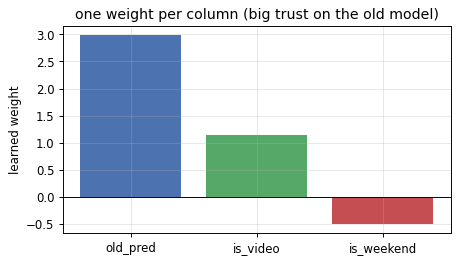

In [29]:
# training data for the new surface: only 300 labels
Xsh_tr, Xnew_tr, y_tr = gen_new(300, 7)
X_train = np.hstack([old_feature(Xsh_tr), Xnew_tr])     # [old_pred | is_video | is_weekend]
new_model = LogisticRegression(max_iter=3000).fit(X_train, y_tr)

names = ["old_pred", "is_video", "is_weekend"]
weights = new_model.coef_[0]
print("STEP 14 — weights the NEW model learned (300 labels):")
for nm, w in zip(names, weights):
    print(f"   {nm:>11}: {w:+.2f}")
print(f"   {'bias':>11}: {new_model.intercept_[0]:+.2f}")

plt.figure(figsize=(5.5, 3.2))
colors = [BLUE, GREEN, RED]
plt.bar(names, weights, color=colors)
plt.axhline(0, color="k", lw=.8)
plt.ylabel("learned weight"); plt.title("one weight per column (big trust on the old model)")
plt.show()
print("old_pred gets the largest weight -> the new model leans heavily on the old model,")
print("then adjusts with is_video (helps) and is_weekend (hurts).")

## Step 15 · Inference for ONE impression, end to end

Let's score a single new impression by hand so the flow is concrete:
**shared features → old model → one number → glue on the 2 new features → weighted sum →
sigmoid → final probability.** We'll reproduce `predict_proba` with plain arithmetic.

In [31]:
# take one fresh impression
Xsh_one, Xnew_one, _ = gen_new(1, 2024)

# 1) shared features -> old model -> one number
old_p = old_model.predict_proba(Xsh_one)[:, 1][0]
print("1) old model reads its 25 shared features -> old_pred =", round(old_p, 3))

# 2) grab the 2 new features
v, wk = Xnew_one[0]
print(f"2) new features -> is_video = {int(v)}, is_weekend = {int(wk)}")

# 3) glue into the new model's 3-number input
x = np.array([old_p, v, wk])
print("3) glued input for the new model:", x.round(3))

# 4) weighted sum = w . x + bias  (the new model's core computation)
w = new_model.coef_[0]; b = new_model.intercept_[0]
score = float(np.dot(w, x) + b)
terms = "  +  ".join(f"{wi:+.2f}*{xi:g}" for wi, xi in zip(w, x))
print(f"4) score = {terms}  {b:+.2f}  =  {score:.3f}")

# 5) sigmoid -> probability
prob = 1/(1 + np.exp(-score))
print(f"5) probability = sigmoid({score:.3f}) = {prob:.3f}")
print("   check vs model.predict_proba:", round(float(new_model.predict_proba(x.reshape(1,-1))[:,1][0]), 3), "(matches)")

1) old model reads its 25 shared features -> old_pred = 0.63
2) new features -> is_video = 0, is_weekend = 0
3) glued input for the new model: [0.63 0.   0.  ]
4) score = +2.98*0.630368  +  +1.15*0  +  -0.50*0  -1.80  =  0.077
5) probability = sigmoid(0.077) = 0.519
   check vs model.predict_proba: 0.519 (matches)


## Step 16 · Does it actually help? scratch vs old-only vs transfer

Three ways to serve the new surface, across different label budgets:
- **from scratch** — train on all 27 raw features (25 shared + 2 new) using only the few
  labels. With so many features and so few rows it **overfits**.
- **old model only** — reuse the old model as-is. It's stuck below the ceiling because it
  **can't see the 2 new features**.
- **transfer** — old model's prediction **plus** the 2 new features (what we built). Best of
  both: the old model's mastery **and** the new signal.

 labels   scratch  old-only  transfer
    100     0.752     0.767     0.822
    200     0.801     0.767     0.815
    500     0.816     0.767     0.829
   1000     0.822     0.767     0.829
   5000     0.831     0.767     0.829


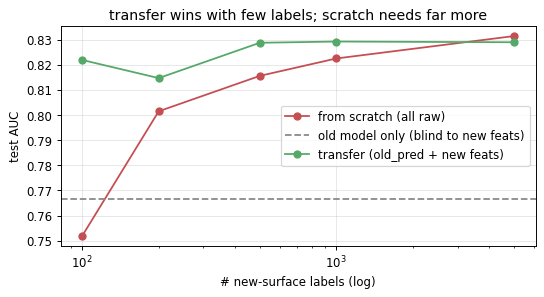

In [33]:
def score_scratch(n):
    Xsh, Xnew, y = gen_new(n, 7)
    m = LogisticRegression(max_iter=3000).fit(np.hstack([Xsh, Xnew]), y)
    return roc_auc_score(y_test, m.predict_proba(np.hstack([Xsh_test, Xnew_test]))[:, 1])

def score_transfer(n):
    Xsh, Xnew, y = gen_new(n, 7)
    m = LogisticRegression(max_iter=3000).fit(np.hstack([old_feature(Xsh), Xnew]), y)
    return roc_auc_score(y_test, m.predict_proba(np.hstack([old_feature(Xsh_test), Xnew_test]))[:, 1])

label_counts = [100, 200, 500, 1000, 5000]
scratch  = [score_scratch(n)  for n in label_counts]
transfer = [score_transfer(n) for n in label_counts]
old_only = roc_auc_score(y_test, old_model.predict_proba(Xsh_test)[:, 1])

print(f"{'labels':>7}{'scratch':>10}{'old-only':>10}{'transfer':>10}")
for n, s, t in zip(label_counts, scratch, transfer):
    print(f"{n:>7}{s:>10.3f}{old_only:>10.3f}{t:>10.3f}")

plt.figure(figsize=(6.5, 3.6))
plt.plot(label_counts, scratch, "o-", color=RED, label="from scratch (all raw)")
plt.axhline(old_only, color=GRAY, ls="--", label="old model only (blind to new feats)")
plt.plot(label_counts, transfer, "o-", color=GREEN, label="transfer (old_pred + new feats)")
plt.xscale("log"); plt.xlabel("# new-surface labels (log)"); plt.ylabel("test AUC"); plt.legend()
plt.title("transfer wins with few labels; scratch needs far more"); plt.show()

## Step 17 · The catch — negative transfer

Transfer is a *hypothesis*, not a guarantee. If the old model solved a **different** problem,
its prediction is misleading and leaning on it does **worse than scratch**. We build a
**mismatched** old model (trained toward unrelated weights) and reuse it — AUC drops. Always
validate that the old model actually fits the new task (e.g., beats a scratch baseline).

with 300 labels:
  scratch                     AUC 0.800
  transfer from GOOD old model  AUC 0.828  (helps)
  transfer from WRONG old model AUC 0.674  (hurts! negative transfer)


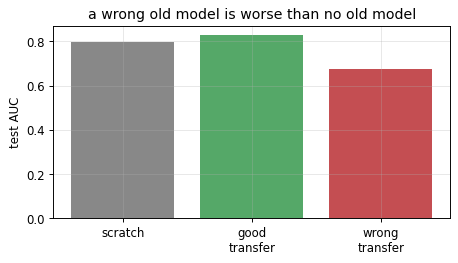

In [35]:
# a mismatched "old model": trained on the same features but a DIFFERENT relationship
w_wrong = np.random.default_rng(777).normal(0, 1, D_SHARED)
rb = np.random.default_rng(2); Xb = gen_shared(40000, rb)
yb = (rb.random(40000) < 1/(1 + np.exp(-(Xb @ w_wrong - 0.3)))).astype(int)
wrong_model = LogisticRegression(max_iter=3000).fit(Xb, yb)
def wrong_feature(Xshared):
    return wrong_model.predict_proba(Xshared)[:, 1].reshape(-1, 1)

Xsh, Xnew, y = gen_new(300, 7)
a_scratch = score_scratch(300)
a_good    = score_transfer(300)
a_bad     = roc_auc_score(y_test,
              LogisticRegression(max_iter=3000).fit(np.hstack([wrong_feature(Xsh), Xnew]), y)
              .predict_proba(np.hstack([wrong_feature(Xsh_test), Xnew_test]))[:, 1])
print("with 300 labels:")
print(f"  scratch                     AUC {a_scratch:.3f}")
print(f"  transfer from GOOD old model  AUC {a_good:.3f}  (helps)")
print(f"  transfer from WRONG old model AUC {a_bad:.3f}  (hurts! negative transfer)")
plt.figure(figsize=(5.5, 3.2))
plt.bar(["scratch", "good\ntransfer", "wrong\ntransfer"], [a_scratch, a_good, a_bad],
        color=[GRAY, GREEN, RED])
plt.ylabel("test AUC"); plt.title("a wrong old model is worse than no old model"); plt.show()

---
# Part C · Distillation

## Step 18 · Teacher vs student

**Distillation** trains a small, **fast student** to imitate a big, **slow teacher**. Why?
The teacher may be too slow to serve online, or you may have lots of **unlabeled** traffic
the teacher can label cheaply. Here the teacher is a 400-tree gradient boosting model (strong
but heavy); the student will be a light logistic model. The task has a 3-way interaction and
a sine wave — signal the light student can only *partly* capture, so it will stay a bit below
the teacher (that's the quality/latency tradeoff).

In [38]:
from sklearn.ensemble import GradientBoostingClassifier
def make2(n, seed):
    r = np.random.default_rng(seed); X = r.normal(0, 1, (n, 8))
    logit = (1.3*X[:,0] - 1.0*X[:,1] + 1.2*X[:,2]*X[:,3]
             + 1.6*X[:,2]*X[:,3]*X[:,4] + 0.8*np.sin(2.5*X[:,5]) - 0.4*X[:,6] - 0.2)
    y = (r.random(n) < 1/(1+np.exp(-logit))).astype(int)
    return X, y

Xtest, ytest = make2(6000, 4)
teacher = GradientBoostingClassifier(max_depth=4, n_estimators=400).fit(*make2(25000, 10))
auc_teacher = roc_auc_score(ytest, teacher.predict_proba(Xtest)[:,1])
print("teacher AUC (strong, but slow to serve):", round(auc_teacher, 3))

teacher AUC (strong, but slow to serve): 0.855


## Step 19 · Temperature & "dark knowledge"

A **hard label** says only 0 or 1. The teacher's **probability** says much more: a negative
scored 0.45 is "almost a click," while 0.02 is "clearly not." That extra shading is **dark
knowledge**. **Temperature** `T` softens probabilities (divide the logit by `T`) to make the
shading easier for the student to see. Let's visualize the softening.

hard labels would be [1 1 0 0] - the student would never learn how 'close' B and C were.


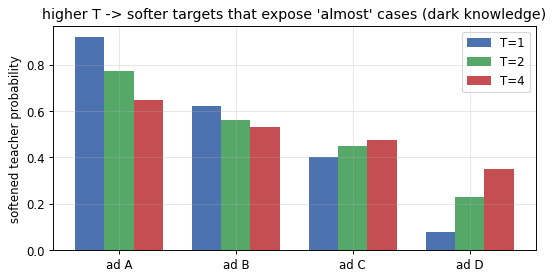

In [40]:
def soften(p, T):
    z = np.log(np.clip(p, 1e-6, 1-1e-6) / (1 - np.clip(p, 1e-6, 1-1e-6)))
    return 1 / (1 + np.exp(-z / T))

items = ["ad A", "ad B", "ad C", "ad D"]
p_teacher = np.array([0.92, 0.62, 0.40, 0.08])
xb = np.arange(len(items)); w = 0.25
plt.figure(figsize=(6.5,3.4))
for j, (T, c) in enumerate([(1, BLUE), (2, GREEN), (4, RED)]):
    plt.bar(xb + (j-1)*w, soften(p_teacher, T), w, color=c, label=f"T={T}")
plt.xticks(xb, items); plt.ylabel("softened teacher probability"); plt.legend()
plt.title("higher T -> softer targets that expose 'almost' cases (dark knowledge)"); plt.show()
print("hard labels would be", (p_teacher>0.5).astype(int), "- the student would never learn how 'close' B and C were.")

## Step 20 · Distill — the teacher teaches the student

Two students, both light logistic models (with interaction features so they *can* learn a
bit):
- **hard student:** trained on only **400 hard labels** → overfits, underperforms.
- **distilled student:** the teacher labels a big **unlabeled pool (20,000 rows)** with soft
  scores; the student learns from those. It sees far more supervision → much better AUC,
  approaching (but below) the teacher.

teacher (strong/slow)          AUC 0.855
student, 400 HARD labels       AUC 0.773
student, 20k teacher SOFT labels AUC 0.817  (+0.044 over hard)


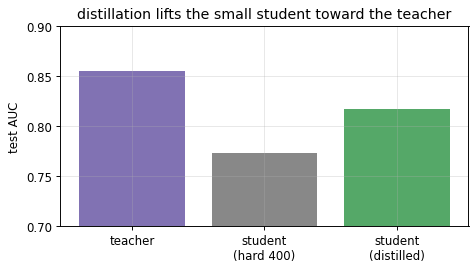

In [42]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

def student_clf():   # small + fast: interaction features + logistic
    return make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(),
                         LogisticRegression(max_iter=4000, C=0.5))
def student_reg():   # same shape, regresses onto teacher logits
    return make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(), Ridge(alpha=1.0))

Xhard, yhard = make2(400, 3)                         # few hard labels
hard = student_clf().fit(Xhard, yhard)
auc_hard = roc_auc_score(ytest, hard.predict_proba(Xtest)[:,1])

Xpool, _ = make2(20000, 5)                           # big UNLABELED pool
soft = np.clip(teacher.predict_proba(Xpool)[:,1], 1e-6, 1-1e-6)
distilled = student_reg().fit(Xpool, np.log(soft/(1-soft)))   # learn the teacher's soft logits
auc_distilled = roc_auc_score(ytest, distilled.predict(Xtest))

print(f"teacher (strong/slow)          AUC {auc_teacher:.3f}")
print(f"student, 400 HARD labels       AUC {auc_hard:.3f}")
print(f"student, 20k teacher SOFT labels AUC {auc_distilled:.3f}  (+{auc_distilled-auc_hard:.3f} over hard)")
plt.figure(figsize=(5.8,3.3))
plt.bar(["teacher","student\n(hard 400)","student\n(distilled)"], [auc_teacher, auc_hard, auc_distilled],
        color=[PURPLE, GRAY, GREEN])
plt.ylabel("test AUC"); plt.ylim(0.7, 0.9); plt.title("distillation lifts the small student toward the teacher"); plt.show()

## Step 21 · The quality-vs-latency tradeoff

The distilled student is a little **below** the teacher but **much cheaper to serve**. That
trade can be a win: if latency is the bottleneck, a 5 ms student at slightly lower AUC beats
a 40 ms teacher you can't afford to run online. (The ms numbers below are illustrative,
matching the lesson.)

teacher: AUC 0.855 @ ~40 ms   vs   student: AUC 0.817 @ ~5 ms (~8x faster)


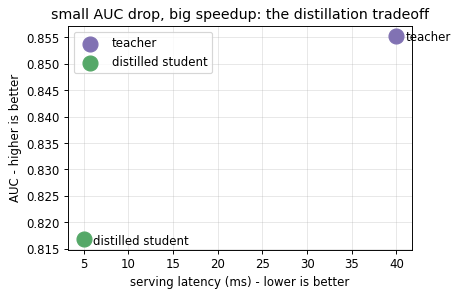

In [44]:
serving_ms = {"teacher": 40, "distilled student": 5}
aucs       = {"teacher": auc_teacher, "distilled student": auc_distilled}
plt.figure(figsize=(5.5,3.6))
for name, c in [("teacher", PURPLE), ("distilled student", GREEN)]:
    plt.scatter(serving_ms[name], aucs[name], s=160, color=c, label=name, zorder=3)
    plt.annotate(name, (serving_ms[name], aucs[name]), textcoords="offset points", xytext=(8, -4))
plt.xlabel("serving latency (ms) - lower is better"); plt.ylabel("AUC - higher is better")
plt.title("small AUC drop, big speedup: the distillation tradeoff"); plt.legend(); plt.show()
print(f"teacher: AUC {auc_teacher:.3f} @ ~40 ms   vs   student: AUC {auc_distilled:.3f} @ ~5 ms (~8x faster)")

## Step 22 · The catch — distillation copies the teacher's bias

Distillation makes serving cheaper; it does **not** fix a bad teacher. If the teacher learned
from a biased policy, the student inherits that bias. So keep the teacher as an offline
reference, check student-vs-teacher disagreement on important slices, and **recalibrate**
(Part of M8) — matching logits doesn't guarantee good serving probabilities.

correlation between teacher and student scores: 0.895 -> student mimics the teacher (bias included)


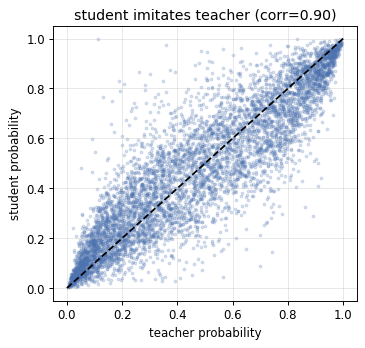

In [46]:
# the student closely tracks the teacher's ranking -> it also copies whatever the teacher got wrong
p_t = teacher.predict_proba(Xtest)[:,1]
p_s = 1/(1+np.exp(-distilled.predict(Xtest)))
corr = np.corrcoef(p_t, p_s)[0,1]
print("correlation between teacher and student scores:", round(corr, 3), "-> student mimics the teacher (bias included)")
plt.figure(figsize=(4.4,4.2))
plt.scatter(p_t, p_s, s=5, alpha=.2, color=BLUE)
plt.plot([0,1],[0,1],"k--"); plt.xlabel("teacher probability"); plt.ylabel("student probability")
plt.title(f"student imitates teacher (corr={corr:.2f})"); plt.show()

---
## Recap — the M9 toolkit

**Cold-start (Part A).** New items/users/systems have almost no evidence, so a raw early rate
(2/20 = 10%) is noise. Anchor on a **prior**, then blend in the learned rate in proportion to
evidence: `p = (1-c)·prior + c·learned` with `c = n/(n+k)`. Gate the cold→warm handoff with
**exit criteria** (min impressions, min positives, stable calibration) and log the regime.
This is what keeps ad **budgets** from chasing lucky spikes.

**Transfer (Part B).** With few target labels, a from-scratch model flounders. **Reuse a
related source** (here, its prediction as a feature) to reach the ceiling with ~100 labels
instead of ~10,000 — but validate fit, because a mismatched source causes **negative
transfer** (worse than scratch).

**Distillation (Part C).** Train a small, fast **student** to imitate a strong, slow
**teacher**. **Temperature** exposes the teacher's **dark knowledge** (how "close" the
negatives were), and letting the teacher label a big **unlabeled pool** lifts the student
well above training on a few hard labels — at a fraction of the serving cost. It copies the
teacher's **bias**, so keep evaluating slices and recalibrate.

**Where this connects:** M9 is how you launch responsibly with little data. It leans on M8
(calibrate the blended/distilled scores) and feeds M10 (the implicit, delayed labels these
systems learn from as evidence finally arrives).